# **Algoritmos de Monte Carlo e Cadeias de Markov - PESC/COPPE/UFRJ - 2026/1**
## **Projeto Final — [TÍTULO]**
### **Prof. Daniel Ratton Figueiredo**
#### **Roberto Leonie Ferreira Moreira (DRE: 126232985)**


## 1. Importando dependências e definindo parâmetros de plotagem

In [347]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from tqdm import tqdm

plt.rcParams['figure.figsize'] = [10, 5]
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-whitegrid')

## 2. Definição do modelo S-I-R
a partir dos hiperparâmetros $\beta$ e $\gamma$, assim como um instante de tempo $t$, dados sintéticos $y_t, 1 < t < T$ e população de $N$ indivíduos inicialmente suscetíveis ao patógeno.

In [348]:
def sir_model(t, y, beta, gamma, N) :
  S, I, R = y
  dS_dt = -(beta * I * S) / N
  dI_dt = (beta * I * S) / N - (gamma * I)
  dR_dt = gamma * I

  return [dS_dt, dI_dt, dR_dt]

## 3. Gerando dados sintéticos (+ ruído)
configurando número $N$ de indivíduos, desvio padrão $\sigma$ — a intensidade do ruído gaussiano —, intervalo de tempo de observação `observation_time` de $[0, T]$, definindo $T+1$ pontos através de `eval_time`. Além disso, para as condições iniciais da epidemia, sejam

*   $I_0 = 1$ (um infectado)
*   $R_0 = 0$ (zero recuperados; não confundir com o número básico de reprodução)
*   $S_0 = N - (I_0 + R_0)$ (praticamente toda a população inicialmente suscetível).

Além disso, sejam `real_beta` e `real_gamma` os reais hiperparâmetros $\beta$ e $\gamma$ que desejamos predizer.




In [349]:
# definindo uma populacao $N$ de 1 milhao,
# real_beta=0.3 e real_gamma=0.1
N = 1_000_000
real_beta = 0.3
real_gamma = 0.1

In [350]:
# para parametros observados em:
# https://people.wku.edu/lily.popova.zhuhadar/
def initial_conditions(N,
                       real_beta,
                       real_gamma,
                       I_0=1,
                       R_0=0,
                       ) :
    S_0 = N - (I_0 + R_0)
    y_0 = [S_0, I_0, R_0]

    return y_0

In [351]:
# definindo um intervalo de tempo de um ano (365 dias)
stop = 365
observation_time = (0, stop)
eval_time = np.linspace(0, stop, stop + 1)

In [352]:
# resolvendo a EDO real
def ode_solver(N, real_beta, real_gamma) :
  y_0 = initial_conditions(N, real_beta, real_gamma)

  solver = solve_ivp(sir_model,
                     observation_time,
                     y_0, args=(real_beta, real_gamma, N),
                     t_eval=eval_time)

  S_candidate_result = solver.y[0]
  I_candidate_result = solver.y[1]
  R_candidate_result = solver.y[2]

  # Ensure the returned solution has the expected length.
  # If not, fill the rest with np.inf to assign a very low weight in IS.
  if len(I_candidate_result) != len(eval_time):
      I_full = np.full_like(eval_time, np.inf, dtype=float)
      I_full[:len(I_candidate_result)] = I_candidate_result
      return I_full
  else:
      return S_candidate_result, I_candidate_result, R_candidate_result

In [353]:
def gaussian_noise(sigma, seed=42) :
  S_real, I_real, R_real = ode_solver(N, real_beta, real_gamma)

  # std_dev = desvio padrao (sigma)
  np.random.seed(seed)
  Y = I_real + np.random.normal(0, sigma, size=len(eval_time))

  return Y, S_real, I_real, R_real, eval_time


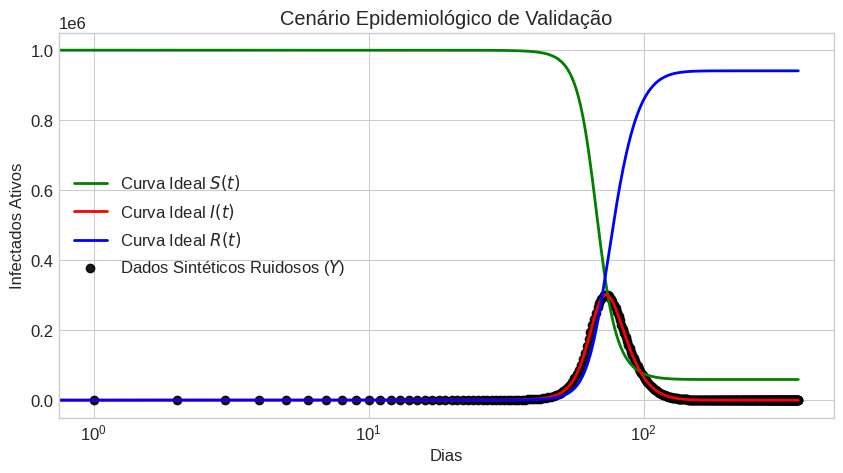

In [354]:
def plot_sint_X_real() :
  Y, S_real, I_real, R_real, eval_time = gaussian_noise(sigma=25.0)

  plt.figure()
  plt.plot(eval_time, S_real, 'g-', label='Curva Ideal $S(t)$', linewidth=2)
  plt.plot(eval_time, I_real, 'r-', label='Curva Ideal $I(t)$', linewidth=2)
  plt.plot(eval_time, R_real, 'b-', label='Curva Ideal $R(t)$', linewidth=2)
  plt.scatter(eval_time, Y, color='black', alpha=0.9, label='Dados Sintéticos Ruidosos ($Y$)')
  plt.title('Cenário Epidemiológico de Validação')
  plt.xlabel('Dias')
  plt.ylabel('Infectados Ativos')
  plt.xscale('log')
  plt.legend()
  plt.savefig('dados_sinteticos.png', dpi=300, bbox_inches='tight') # Já salva a imagem para o LaTeX
  plt.show()

plot_sint_X_real()

## 4. O Importance Sampling

In [355]:
# distribuicao proposta q($\theta=(\beta,\gamma)$): uniforme bivariada
BETA_MIN, BETA_MAX = 0.1, 0.8
GAMMA_MIN, GAMMA_MAX = 0.01, 0.5

def importance_sampling(rounds,
                        beta_min=BETA_MIN,
                        beta_max=BETA_MAX,
                        gamma_min=GAMMA_MIN,
                        gamma_max=GAMMA_MAX,
                        sigma=25.0) :


  beta_samples = np.random.uniform(beta_min, beta_max, rounds)
  gamma_samples = np.random.uniform(gamma_min, gamma_max, rounds)

  Y = gaussian_noise(sigma)[0]

  log_w = np.zeros(rounds)

  print("Iniciando as simulações via Importance Sampling...")

  for i in tqdm(range(rounds), desc="Rodadas: "):
    beta_i = beta_samples[i]
    gamma_i = gamma_samples[i]

    I_candidate = ode_solver(N,
                        real_beta=beta_i,
                        real_gamma=gamma_i)[1]

    # calcula a log-verossimilhança para evitar underflow numerico
    residual = Y - I_candidate
    log_w[i] = - (len(eval_time) / 2) * np.log(2 * np.pi * sigma**2) - np.sum(residual**2) / (2 * sigma**2)

  w = np.exp(log_w - np.max(log_w))
  W = w / np.sum(w)

  # estimadores finais via media ponderada
  hat_beta = np.sum(beta_samples * W)
  hat_gamma = np.sum(gamma_samples * W)

  print("Simulação concluída!")

  return hat_beta, hat_gamma, beta_samples, gamma_samples, W


## 5. Obtenção de métricas e resultados

In [356]:
def analytics(rounds) :
  hat_beta, hat_gamma, \
    beta_samples, gamma_samples, W = importance_sampling(rounds)

  # Cálculos dos Erros Absolutos (para não repetir código dentro do print)
  erro_abs_beta = abs(real_beta - hat_beta)
  erro_abs_gamma = abs(real_gamma - hat_gamma)

  real_R0 = real_beta / real_gamma
  hat_R0 = hat_beta / hat_gamma
  erro_abs_R0 = abs(real_R0 - hat_R0)

  print("-" * 85) # Aumentei um pouco o traço para caber a nova coluna
  print("RELATORIO DE CONVERGENCIA E ANALISE DE ERROS")
  print("-" * 85)

  # Print do Beta com Erro Absoluto e Erro Relativo (%)
  print(f"Beta Real:    {real_beta:.4f}  |  Beta Estimado:    {hat_beta:.4f}  |  Erro Abs: {erro_abs_beta:.4f}  |  Erro Rel: {(erro_abs_beta / real_beta) * 100:.2f}%")

  # Print do Gamma com Erro Absoluto e Erro Relativo (%)
  print(f"Gamma Real:   {real_gamma:.4f}  |  Gamma Estimado:   {hat_gamma:.4f}  |  Erro Abs: {erro_abs_gamma:.4f}  |  Erro Rel: {(erro_abs_gamma / real_gamma) * 100:.2f}%")

  # Print do R0 com Erro Absoluto e Erro Relativo (%)
  print(f"R_0 Real:     {real_R0:.4f}  |  R_0 Estimado:     {hat_R0:.4f}  |  Erro Abs: {erro_abs_R0:.4f}  |  Erro Rel: {(erro_abs_R0 / real_R0) * 100:.2f}%")
  print("-" * 85)

  return hat_beta, hat_gamma, \
    beta_samples, gamma_samples, W

In [357]:
def plot_data(rounds) :
  hat_beta, hat_gamma, beta_samples, gamma_samples, W = analytics(rounds)

  returnable = [hat_beta, hat_gamma, beta_samples, gamma_samples, W]
  return returnable

## 6. Gráfico de dispersão (*scatter plot*) das amostras $\theta_i$ e dos estimadores $\hat{\theta}$ gerados

In [358]:
def scatter_plot(rounds) :
  hat_beta, hat_gamma, beta_samples, gamma_samples, W = plot_data(rounds)

  plt.figure()
  scatter = plt.scatter(beta_samples, gamma_samples, c=W,
                       cmap='viridis', s=2, alpha=0.8)
  plt.colorbar(scatter, label='Peso de importância normalizado ($W_i$)')

  plt.scatter(real_beta, real_gamma, color='red', marker='X', s=150, label='Valor Real ($\\theta^*$)')
  plt.scatter(hat_beta, hat_gamma, color='cyan', marker='o', s=100, label='Valor Estimado ($\\hat{\\theta}$)')

  plt.title('Espaço de parâmetros amostrado pelo Importance Sampling')
  plt.xlabel('Taxa de Transmissão ($\\beta$)')
  plt.ylabel('Taxa de Recuperação ($\\gamma$)')
  plt.xlim(BETA_MIN, BETA_MAX)
  plt.ylim(GAMMA_MIN, GAMMA_MAX)

  plt.legend(loc='upper right',
             fontsize='small',
             frameon=True,
             facecolor='white',
             framealpha=0.99,
             edgecolor='gray')


  plt.savefig('convergencia_parametros.png', dpi=300, bbox_inches='tight')
  plt.show()
  print("-" * 80)
  print("-" * 80)

  return hat_beta, hat_gamma

Iniciando as simulações via Importance Sampling...


Rodadas: 100%|██████████| 1000/1000 [00:10<00:00, 95.90it/s]


Simulação concluída!
-------------------------------------------------------------------------------------
RELATORIO DE CONVERGENCIA E ANALISE DE ERROS
-------------------------------------------------------------------------------------
Beta Real:    0.3000  |  Beta Estimado:    0.3207  |  Erro Abs: 0.0207  |  Erro Rel: 6.90%
Gamma Real:   0.1000  |  Gamma Estimado:   0.1330  |  Erro Abs: 0.0330  |  Erro Rel: 32.97%
R_0 Real:     3.0000  |  R_0 Estimado:     2.4118  |  Erro Abs: 0.5882  |  Erro Rel: 19.61%
-------------------------------------------------------------------------------------


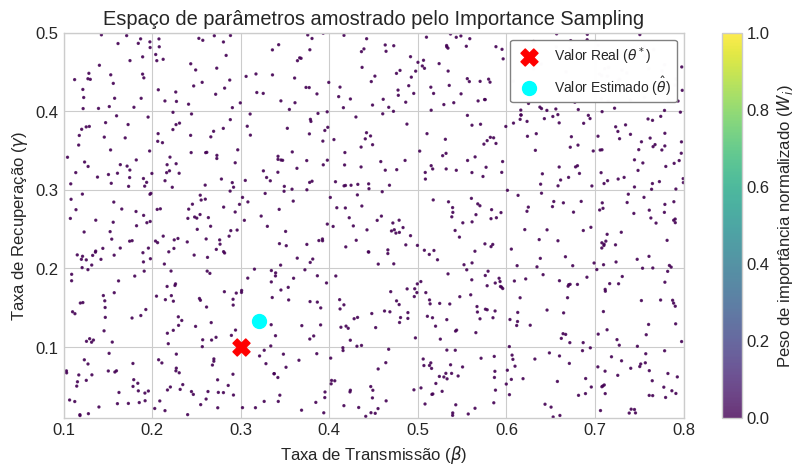

--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
Iniciando as simulações via Importance Sampling...


Rodadas: 100%|██████████| 10000/10000 [01:02<00:00, 160.26it/s]


Simulação concluída!
-------------------------------------------------------------------------------------
RELATORIO DE CONVERGENCIA E ANALISE DE ERROS
-------------------------------------------------------------------------------------
Beta Real:    0.3000  |  Beta Estimado:    0.3036  |  Erro Abs: 0.0036  |  Erro Rel: 1.20%
Gamma Real:   0.1000  |  Gamma Estimado:   0.0995  |  Erro Abs: 0.0005  |  Erro Rel: 0.53%
R_0 Real:     3.0000  |  R_0 Estimado:     3.0522  |  Erro Abs: 0.0522  |  Erro Rel: 1.74%
-------------------------------------------------------------------------------------


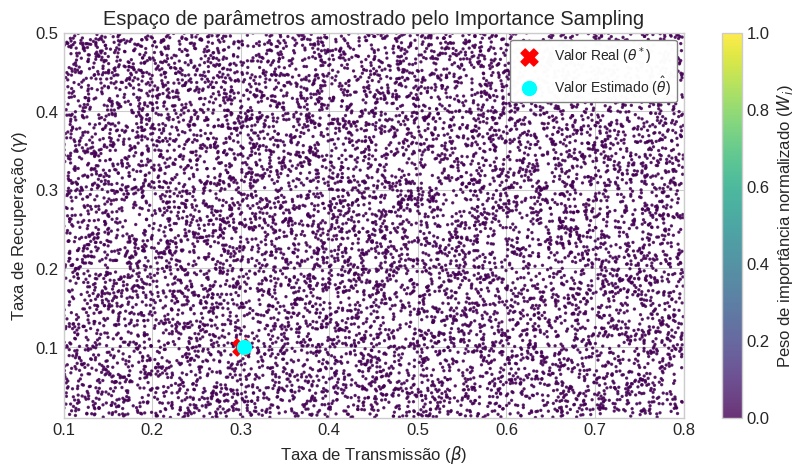

--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
Iniciando as simulações via Importance Sampling...


Rodadas: 100%|██████████| 100000/100000 [11:04<00:00, 150.60it/s]


Simulação concluída!
-------------------------------------------------------------------------------------
RELATORIO DE CONVERGENCIA E ANALISE DE ERROS
-------------------------------------------------------------------------------------
Beta Real:    0.3000  |  Beta Estimado:    0.3011  |  Erro Abs: 0.0011  |  Erro Rel: 0.38%
Gamma Real:   0.1000  |  Gamma Estimado:   0.1014  |  Erro Abs: 0.0014  |  Erro Rel: 1.44%
R_0 Real:     3.0000  |  R_0 Estimado:     2.9687  |  Erro Abs: 0.0313  |  Erro Rel: 1.04%
-------------------------------------------------------------------------------------


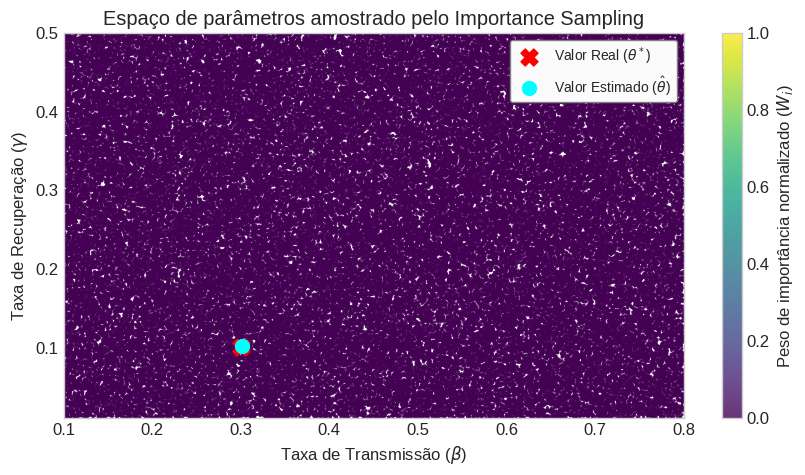

--------------------------------------------------------------------------------
--------------------------------------------------------------------------------


In [359]:
hat_beta, hat_gamma = [], []

rounds = [10**i for i in range(3,6)]
for i in rounds:
  hb, hg = scatter_plot(i)
  hat_beta.append(hb)
  hat_gamma.append(hg)

## 7. Cálculo da *Distância de Variação Total* ($d_{TV}$)

$$d_{TV}(\alpha, \beta) = \frac{1}{2} \sum_{k} \mid \alpha_k - \beta_k \mid$$

para medir a distância entre dois vetores $\alpha$ e $\beta$ quaisquer, $0 \leq d_{TV} \leq 1$. Para nosso exemplo, desejamos calcular $d_{TV}(\theta^*, \hat{\theta})$.


In [363]:
print(len(hat_beta))
print(len(hat_gamma))

3
3


In [382]:
def total_variation(v1, v2) :
  try :
    assert len(v1) == len(v2)
  except AssertionError :
    print("Erro: vetores com dimensoes distintas!")
    return

  acc = 0
  for k in range(len(v1)) :
    acc += abs(v1[k] - v2[k])

  d_TV = acc / 2
  print(f"v1 = {v1}")
  print(f"v2 = {v2}")
  print(f"Distancia de variacao total entre vetores: {d_TV:.4f}\n")

In [383]:
for i in range(len(hat_beta)):
    theta = [real_beta, real_gamma]
    hat_theta = [hat_beta[i], hat_gamma[i]]

    # print(theta)
    # print(hat_theta)

    total_variation(theta, hat_theta)


v1 = [0.3, 0.1]
v2 = [np.float64(0.3207032364814273), np.float64(0.13297366405674602)]
Distancia de variacao total entre vetores: 0.0268

v1 = [0.3, 0.1]
v2 = [np.float64(0.30361379796210775), np.float64(0.09947259423267865)]
Distancia de variacao total entre vetores: 0.0021

v1 = [0.3, 0.1]
v2 = [np.float64(0.3011456234763338), np.float64(0.10144137708861942)]
Distancia de variacao total entre vetores: 0.0013

